# EDA de los 3 targets — ¿cómo se ven, de verdad, en todos los receptores?

## Qué pregunta responde este notebook

Ya explicamos, con un jugador real (DeVonta Smith, 2024), qué significa cada uno de los 3
números que el pipeline predice cada semana: recepciones, yardas de recepción y touchdowns de
recepción. Vimos ahí mismo dos cosas concretas: que las yardas pueden ser negativas (semana 7:
-2), y que los touchdowns casi nunca pasan (3 de 9 semanas).

Este notebook responde la pregunta siguiente, distinta: **¿ese patrón de un jugador se repite en
todos los receptores, o fue una casualidad de ese caso?** — con las distribuciones reales,
sobre 2 temporadas completas (2024-2025), no un solo caso.

## Por qué importa antes de construir cualquier modelo

La forma de estos 3 números decide qué herramientas tienen sentido usarse en la Fase 5. Si un
target tiene muchos ceros y pocos valores altos, un modelo pensado para una campana simétrica
(como una regresión lineal común) va a fallar sistemáticamente en los extremos — por eso el plan
del proyecto ya contempla probar modelos como Poisson/Tweedie, pensados justo para este tipo de
forma, en vez de asumir que un solo tipo de modelo sirve para los 3 targets por igual.

In [1]:
import sys
sys.path.insert(0, "../src")
import data

import matplotlib.pyplot as plt

stats = data.cargar_stats_semanales([2024, 2025])
wr = stats[stats["position"] == "WR"].copy()
print("filas WR totales (todas, incluye jugadores casi sin participacion esa semana):", wr.shape[0])

filas WR totales (todas, incluye jugadores casi sin participacion esa semana): 4952


## Primer corte: todas las filas WR, sin filtrar

Esto incluye a cualquier jugador con `position == "WR"` esa semana, aunque no haya recibido
ningún pase (ej. suplente que no entró, o entró solo en jugadas de carrera). Se muestra así
primero a propósito — para ver qué tan grande es ese grupo antes de decidir si hay que
filtrarlo.

In [2]:
targets_cols = ["receptions", "receiving_yards", "receiving_tds"]
resumen = wr[targets_cols].describe().T
resumen["% en cero"] = [round((wr[c] == 0).mean() * 100, 1) for c in targets_cols]
resumen

,count,mean,std,min,25%,50%,75%,max,% en cero
receptions,4952.0,2.518982,2.469209,0.0,1.0,2.0,4.0,16.0,24.2
receiving_yards,4952.0,31.695073,35.133400,-13.0,0.0,20.0,49.0,264.0,24.5
receiving_tds,4952.0,0.203352,0.467101,0.0,0.0,0.0,0.0,3.0,82.3


**Lectura:** un 24.2% de las filas WR tienen 0 recepciones esa semana (y un 15.4% del total ni siquiera tuvo un target — se ve en la siguiente celda). No es "más de la mitad", pero sí una porción real que mezcla dos cosas distintas: receptores que de verdad jugaron poco, y receptores que casi no fueron parte del plan de pases esa semana. `receiving_tds`, en cambio, sí está en 0 la gran mayoría del tiempo (82.3%) incluso sin filtrar nada — la primera señal real de que este target se comporta distinto a los otros dos.

## Segundo corte: solo semanas con al menos 1 target (targets > 0)

Esto es "el jugador fue parte real del plan de pases esa semana", aunque no haya atrapado nada.
Es un filtro más realista para lo que el modelo debería predecir — no tiene mucho sentido
predecir "cuántas yardas va a tener" para alguien que ni siquiera iba a jugar.

In [3]:
wr_activo = wr[wr["targets"] > 0].copy()
print(f"filas WR con al menos 1 target: {wr_activo.shape[0]} de {wr.shape[0]} "
      f"({round(wr_activo.shape[0] / wr.shape[0] * 100, 1)}%)")

resumen_activo = wr_activo[targets_cols].describe().T
resumen_activo["% en cero"] = [round((wr_activo[c] == 0).mean() * 100, 1) for c in targets_cols]
resumen_activo

filas WR con al menos 1 target: 4187 de 4952 (84.6%)


,count,mean,std,min,25%,50%,75%,max,% en cero
receptions,4187.0,2.979221,2.416557,0.0,1.0,2.0,4.0,16.0,10.4
receiving_yards,4187.0,37.481013,35.257280,-13.0,10.0,28.0,56.0,264.0,10.8
receiving_tds,4187.0,0.240506,0.499118,0.0,0.0,0.0,0.0,3.0,79.1


**Lectura:** incluso filtrando a "tuvo al menos 1 target", `receiving_tds` sigue en 0 la gran
mayoría de las semanas (ver `% en cero`) — confirma con volumen real lo que ya vimos en el
ejemplo de un jugador: anotar es un evento raro, no algo que se mueva gradualmente con el uso.
`receptions` y `receiving_yards` bajan su `% en cero`, pero no desaparece del todo — hay semanas
reales donde alguien fue parte del plan de pases y aun así no atrapó nada.

## Las distribuciones, ya sobre el grupo activo (targets > 0)

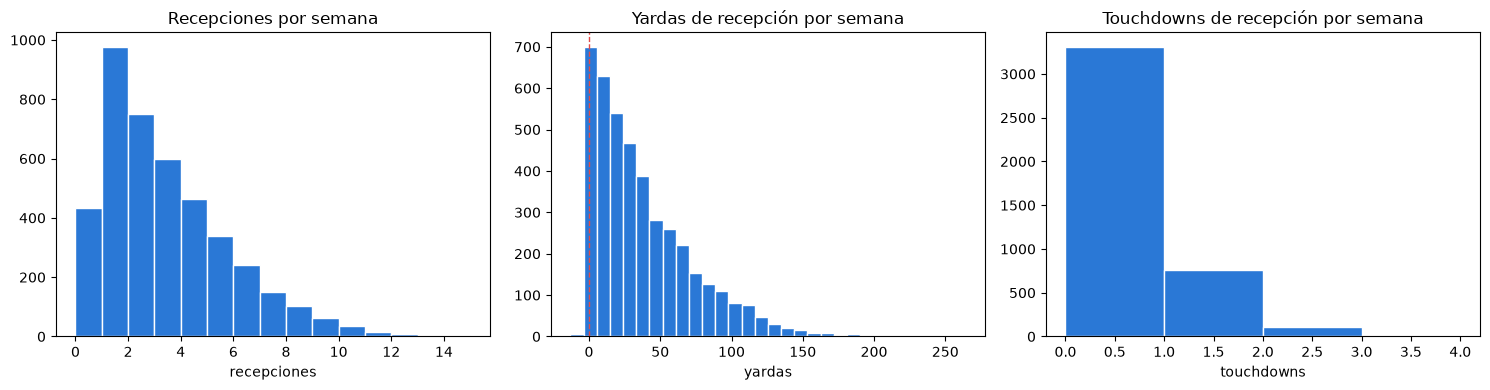

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(wr_activo["receptions"], bins=range(0, 16), color="#2a78d6", edgecolor="white")
axes[0].set_title("Recepciones por semana")
axes[0].set_xlabel("recepciones")

axes[1].hist(wr_activo["receiving_yards"], bins=30, color="#2a78d6", edgecolor="white")
axes[1].set_title("Yardas de recepción por semana")
axes[1].set_xlabel("yardas")
axes[1].axvline(0, color="#e34948", linestyle="--", linewidth=1)

axes[2].hist(wr_activo["receiving_tds"], bins=range(0, 5), color="#2a78d6", edgecolor="white")
axes[2].set_title("Touchdowns de recepción por semana")
axes[2].set_xlabel("touchdowns")

plt.tight_layout()
plt.show()

**Cómo leer esto:**

- **Recepciones**: sesgada a la derecha (muchas semanas de pocas recepciones, pocas semanas de
  muchas) pero razonablemente continua — no salta directo de 0 a un número alto.
- **Yardas**: la misma forma sesgada, y la línea roja marca el 0 — hay una porción real de casos
  a la izquierda de esa línea (yardas negativas), no son errores de captura, ya lo confirmamos
  con el ejemplo real de la semana 7.
- **Touchdowns**: no se parece en nada a las otras dos. Es casi todo 0, con una caída inmediata
  en 1, y casi nada en 2+. Esta forma (un evento raro, de conteo) es la razón concreta por la
  que técnicas para variables de conteo (Poisson/Tweedie) tienen sentido probarlas en la Fase 5,
  y por la que ya se documentó que ningún modelo le gana de forma consistente a "adivinar el
  promedio" para este target específico.

## ¿Qué tan seguido pasan las yardas negativas?

Se mencionó como "caso raro" en el ejemplo de un jugador — aquí se cuantifica sobre todo el
grupo activo, para saber si de verdad es raro o es más común de lo que parece.

In [5]:
negativas = wr_activo[wr_activo["receiving_yards"] < 0]
print(f"semanas con yardas negativas: {negativas.shape[0]} de {wr_activo.shape[0]} "
      f"({round(negativas.shape[0] / wr_activo.shape[0] * 100, 2)}%)")
print()
print("las 5 mas negativas:")
negativas.nsmallest(5, "receiving_yards")[
    ["player_display_name", "season", "week", "targets", "receptions", "receiving_yards"]
]

semanas con yardas negativas: 36 de 4187 (0.86%)

las 5 mas negativas:


,player_display_name,season,week,targets,receptions,receiving_yards
9642,Dyami Brown,2024,10,3,2,-13
25725,Ashton Dulin,2025,8,1,1,-8
21614,Ray-Ray McCloud,2025,4,2,1,-7
6719,Jameson Williams,2024,7,1,1,-4
8668,Jaylen Waddle,2024,9,2,2,-4


## Resumen

| Target | Forma | Qué implica para Fase 4-5 |
|---|---|---|
| Recepciones | Sesgada a la derecha, continua | Modelos de regresión normales son razonables |
| Yardas de recepción | Sesgada a la derecha, con cola negativa real (no error) | Igual razonable para regresión; no "limpiar" los negativos, son datos reales |
| Touchdowns de recepción | Casi todo 0, evento raro de conteo | Vale la pena probar Poisson/Tweedie en Fase 5, no solo regresión estándar; ya documentado que el baseline es difícil de superar |

Además: un 15.4% de las filas WR sin filtrar no tuvieron ni un target esa semana (4,952 filas en total, 4,187 con al menos 1 target) — la Fase 4 debe decidir explícitamente si el modelo se entrena solo sobre semanas activas (`targets > 0`) o sobre todas, con evidencia de cuál da mejores resultados, no por default.

Notebook anterior: [`03_features.ipynb`](03_features.ipynb) · Hallazgos y decisiones:
[`../../../docs/HALLAZGOS.md`](../../../docs/HALLAZGOS.md)